In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
pd.options.mode.use_inf_as_na = True
import tkinter
from tkinter import filedialog

In [2]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()

In [4]:
# df_files = {}
# i = 0

# for root, dirs, files in os.walk(filepath):
#     if ".csv" in str(files) and "Trial" in str(files):
#         for f in listdir(path=root):
#             if ".csv" in str(f):
#                     a = pd.read_csv(root + '\\' + f)
#                     y = a.xs('Y (cm)', axis=1)
#                     x = a.xs('X (cm)', axis=1)
#                     speed = a.xs('SPEED#wcentroid (cm/s)', axis=1)
#                     vy = a.xs('VY (cm/s)', axis=1)
#                     frame = a.frame
#                     df_files[str(i)] = pd.DataFrame({"Y" : y, "X" : x, "Speed" : speed, "VY" : vy, "Frame" : frame, "Trial" : str(f), "Condition" : str(root.rsplit('\\')[-2])})
#                     i = i+1

# complete_df = pd.concat(df_files)

In [3]:
df_files = {}
i = 0

for root, dirs, files in os.walk(filepath):
    if ".csv" in str(files) and "Trial" in str(files):
        for f in listdir(path=root):
            if ".csv" in str(f):
                    a = pd.read_csv(root + '\\' + f)
                    y = a.xs('Y (cm)', axis=1)
                    x = a.xs('X (cm)', axis=1)
                    speed = a.xs('SPEED#wcentroid (cm/s)', axis=1)
                    vy = a.xs('VY (cm/s)', axis=1)
                    frame = a.frame
                    df_files[str(i)] = pd.DataFrame({"Y" : y, "X" : x, "Speed" : speed, "VY" : vy, "Frame" : frame, "Trial" : str(root.rsplit('\\')[-1]), "Condition" : str(root.rsplit('\\')[-2])})
                    i = i+1

complete_df = pd.concat(df_files)

In [4]:
#Cleaning the data: ridding it of infs
clean_complete_df = complete_df.dropna()

clean_complete_df.head()


Y       X  Speed     VY  Frame        Trial Condition
0 0  13.807  12.321  0.000  0.000   12.0  Trial 1 - 1    Trh 5h
  1  13.882  12.219  1.269 -0.006   13.0  Trial 1 - 1    Trh 5h
  2  13.941  12.171  0.796 -0.371   14.0  Trial 1 - 1    Trh 5h
  3  14.083  12.045  1.724  0.482   15.0  Trial 1 - 1    Trh 5h
  4  14.330  11.691  1.772  1.721   16.0  Trial 1 - 1    Trh 5h

In [5]:
conditions = clean_complete_df['Condition'].unique().tolist()

trials_dict = {}

for cond in conditions:
    key = f'{cond}'
    sub_df = clean_complete_df[clean_complete_df['Condition'] == cond] 
    value = sub_df['Trial'].unique().tolist()
    trials_dict[key] = value



In [6]:
#Inserting a distance column
clean_complete_df.insert(4, 'Distance', 0)

In [7]:
for cond in conditions:
    for trial in trials_dict[f'{cond}']:
        sub_df = clean_complete_df[(clean_complete_df['Condition'] == cond) & (clean_complete_df['Trial'] == trial)]
        #Calculating centroid position

        x_centroid_list = []
        y_centroid_list = []

        frame_list = sub_df['Frame'].values.tolist()
        for f in range(0, int(max(frame_list))):
            cropped_pos = sub_df.loc[sub_df['Frame'] == f]
            av_x = cropped_pos['X'].mean()
            x_centroid_list.append(av_x)
            av_y = cropped_pos['Y'].mean()
            y_centroid_list.append(av_y)

        coordlist = list(zip(x_centroid_list, y_centroid_list))
        t = np.arange(np.size(x_centroid_list))

        x_1 = 15
        y_1 = 11

        for f in sub_df.index:
            x_2 = sub_df.X[f]
            y_2 = sub_df.Y[f]
            dist = math.sqrt((x_2-x_1)**2 + (y_2-y_1)**2)
            clean_complete_df.Distance[f] = dist



C:\Users\hpnhp\AppData\Local\Temp\ipykernel_7688\3857916890.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_complete_df.Distance[f] = dist


In [8]:
distance_grouped = clean_complete_df.groupby(['Condition', 'Trial']).Speed.mean()

distance_grouped = distance_grouped.reset_index()

In [9]:
distance_grouped = distance_grouped.pivot(index='Trial', columns='Condition', values = 'Speed')

In [10]:
distance_grouped.head()

Condition,Trh 5h,Trh Fed,WT 24h,WT 5h,WT Fed
Trial,,,,,
Trial 1,NaN,0.871410,NaN,0.828024,0.744821
Trial 1 - 1,0.671859,NaN,0.515236,NaN,NaN
Trial 1 - 2,0.563551,NaN,0.653466,NaN,NaN
Trial 10,NaN,0.660717,NaN,NaN,1.087261
Trial 11,NaN,0.826133,NaN,NaN,1.091414


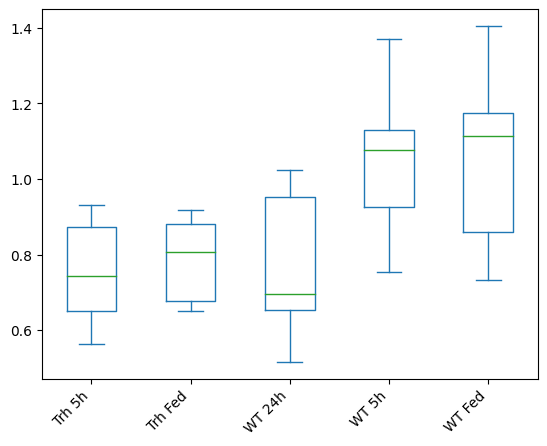

In [11]:
#for index in distance_grouped.index:
    #sbs.boxenplot(data = distance_grouped, x = distance_grouped[index], y = 'Condition')

ax = distance_grouped.plot(kind='box')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels by 45 degrees

plt.show()

#sbs.boxenplot(x='Condition', y='Distance', data=distance_grouped, color='blue', width=0.4)
#plt.legend()
#plt.show()

<AxesSubplot: xlabel='Frame', ylabel='Distance'>

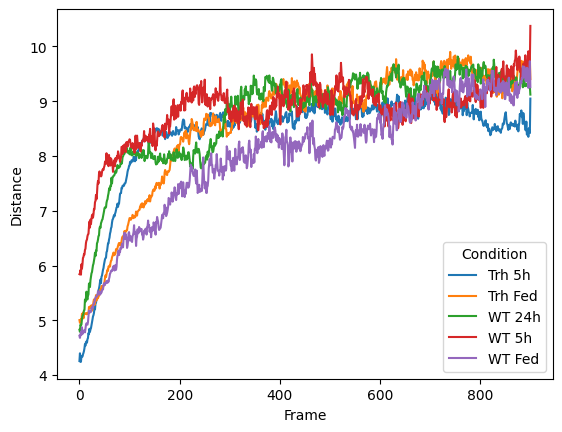

In [12]:
frame_dist_df = clean_complete_df.groupby(['Condition', 'Frame']).Distance.mean()

sbs.lineplot(data = frame_dist_df, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')

<AxesSubplot: xlabel='Frame', ylabel='Distance'>

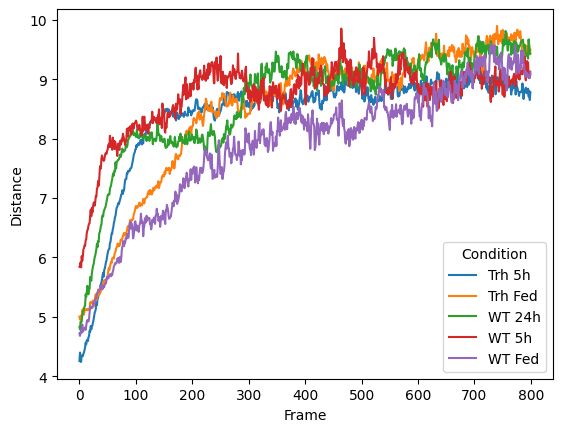

In [13]:
#To analyze cropped parts of the dataset

cropped_ccd = clean_complete_df[clean_complete_df['Frame']<800]

frame_dist_df = cropped_ccd.groupby(['Condition', 'Frame']).Distance.mean()

sbs.lineplot(data = frame_dist_df, x = 'Frame' ,y = frame_dist_df, hue = 'Condition')

In [16]:
#frame_dist_df_WT = frame_dist_df[frame_dist_df['Condition'] == 'WT -Ethanol']

#frame_dist_df = frame_dist_df.reset_index()

In [14]:
def compare_to_constant(df, column_name, constant):
    # Create a new column based on the comparison
    df['Side'] = (df[column_name] < constant).astype(int)
    
    return df

In [15]:
def pref_index_calc(frame_sub_df):            
    sum_side = frame_sub_df['Side'].sum()
    total_side = frame_sub_df['Side'].count()
    if total_side > 0:
        ret_index = sum_side/total_side
    else:
        ret_index = 0
    return ret_index

In [16]:
side_df = clean_complete_df.copy()
side_df = compare_to_constant(side_df, "Y", 14.6)

In [17]:
pref_df = pd.DataFrame(
    {"Condition" : [],
     "Trial" : [],
     "Preference Index" : [],
     "Frame" : []    
     })

for cond in conditions:
    for trial in trials_dict[f'{cond}']:
        sub_df = side_df[(side_df['Condition'] == cond) & (side_df['Trial'] == trial)]
        pref_list = []
        frame_list = sub_df["Frame"].unique().tolist()
        for frame in frame_list:
              frame_sub_df = sub_df[(sub_df['Frame'] == frame)]
              ret_frame = pref_index_calc(frame_sub_df)
              pref_list.append(ret_frame)
        temp_pref_df = pd.DataFrame(
             {    "Condition" : cond,
                  "Trial" : trial,
                  "Preference Index" : pref_list,
                  "Frame" : frame_list
             }
        )
        pref_df = pd.concat([pref_df, temp_pref_df])

In [21]:
# Retention index - bin data into >3cm and <3cm 

# for cond in conditions:
#     for trial in trials_dict[f'{cond}']:
#         sub_df = clean_complete_df[(clean_complete_df['Condition'] == cond) & (clean_complete_df['Trial'] == trial)]
#         list of retention indices per trial per condition - make it a series and then collate them all into a big dataframe
#         index by condition and frame letsgooo - generates means and standard deviation across x trials in yth frame
#         plot mean and std deviation of retention index as lineplot
#         for frame in frame_list:
#               frame_sub_df = sub_df[(sub_df['Frame'] == frame)]
#               sum_side = frame_sub_df['Distance'].sum()
#               total_side = sum_side = frame_sub_df['Distance'].count()
#               ret_index =          

In [18]:
# Grouped Analysis for Preference

pref_grouped_df_mean = pref_df.groupby(['Condition', 'Trial'])["Preference Index"].mean()
retained_grouped_df_mean = pref_df.reset_index()

#retained_grouped_df_mean = retained_grouped_df_mean.pivot(index = "Trial", columns= "Condition", values="Retention")

In [19]:
#retained_grouped_df_mean = retained_grouped_df_mean.reset_index()
retained_grouped_df_mean.head()

,index,Condition,Trial,Preference Index,Frame
0,0,Trh 5h,Trial 1 - 1,0.600000,12.0
1,1,Trh 5h,Trial 1 - 1,0.533333,13.0
2,2,Trh 5h,Trial 1 - 1,0.600000,14.0
3,3,Trh 5h,Trial 1 - 1,0.600000,15.0
4,4,Trh 5h,Trial 1 - 1,0.533333,16.0


In [20]:
retained_grouped_df_mean.drop(columns=["Trial"],inplace=True)

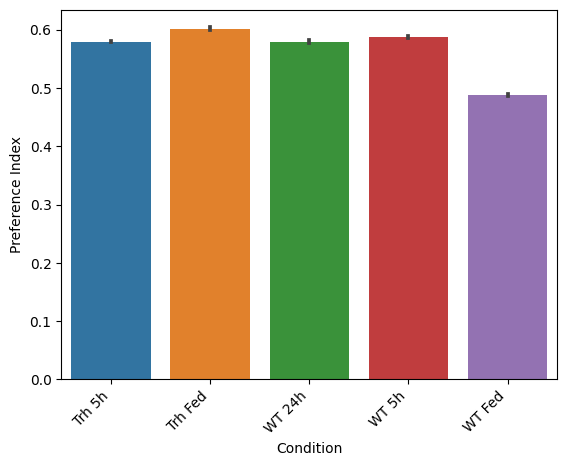

In [21]:
ax = sbs.barplot(data = pref_df, x = "Condition", y = "Preference Index", errorbar="se")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels by 45 degrees

plt.show()

In [22]:
retained_byframe = pref_df.groupby(["Condition", "Frame"])["Preference Index"].mean()

In [23]:
retained_byframe = retained_byframe.reset_index()
retained_byframe.head()

,Condition,Frame,Preference Index
0,Trh 5h,0.0,0.441153
1,Trh 5h,1.0,0.440397
2,Trh 5h,2.0,0.434628
3,Trh 5h,3.0,0.432647
4,Trh 5h,4.0,0.432662


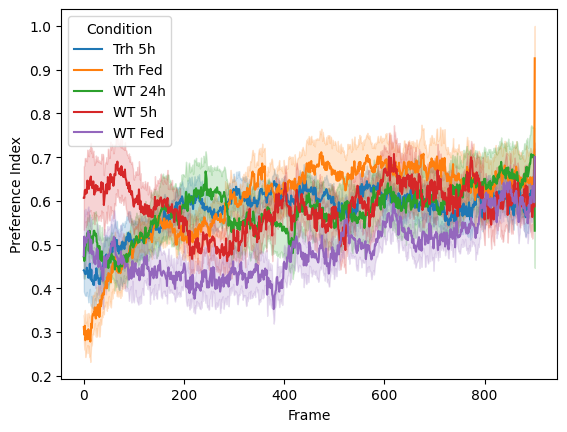

In [24]:
ax = sbs.lineplot(data = pref_df, x = "Frame", y = "Preference Index", hue="Condition", errorbar="se")
plt.show()

In [25]:
pref_df_WT =                  pref_df[(pref_df["Condition"] == "WT Fed") 
                                    | (pref_df["Condition"] == "WT 5h") 
                                    | (pref_df["Condition"] == "WT 24h")
                                    ]



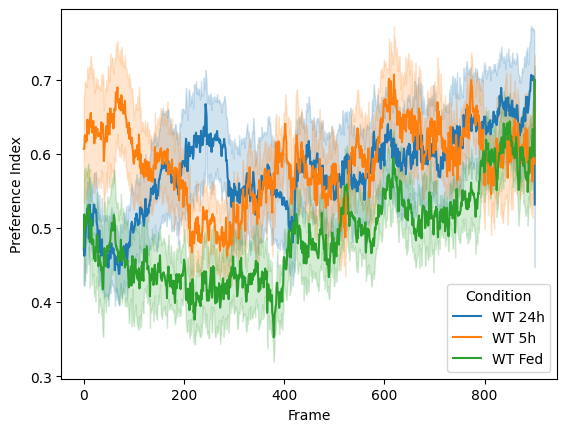

In [26]:
ax = sbs.lineplot(data = pref_df_WT, x = "Frame", y = "Preference Index", hue="Condition", errorbar="se")
plt.show()

In [27]:
retained_df_trh =               pref_df[(pref_df["Condition"] == "Trh Fed") 
                                    | (pref_df["Condition"] == "Trh 5h") 
                                    ]



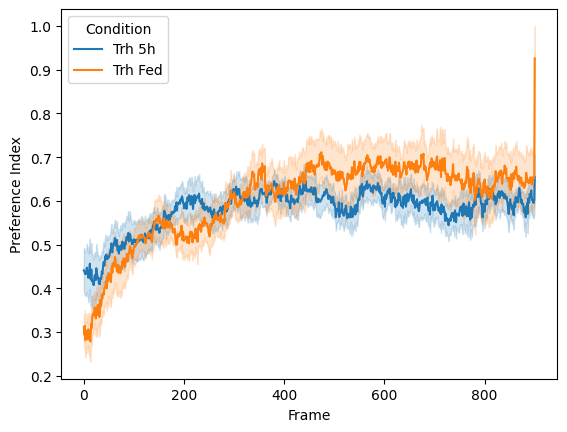

In [28]:
ax = sbs.lineplot(data = retained_df_trh, x = "Frame", y = "Preference Index", hue="Condition", errorbar="se")
plt.show()

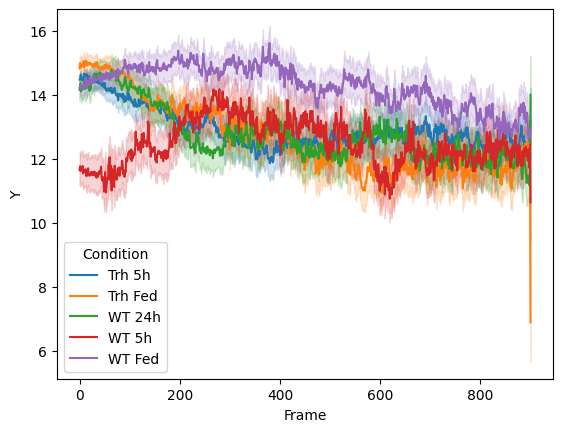

In [53]:
#Plotting Y Axis vs Time

ax = sbs.lineplot(data = clean_complete_df, x = "Frame", y = "Y", hue="Condition", errorbar="se")
plt.show()

In [29]:
y_df_trh =               clean_complete_df[(clean_complete_df["Condition"] == "Trh Fed") 
                                    | (clean_complete_df["Condition"] == "Trh 5h") 
                                    ]



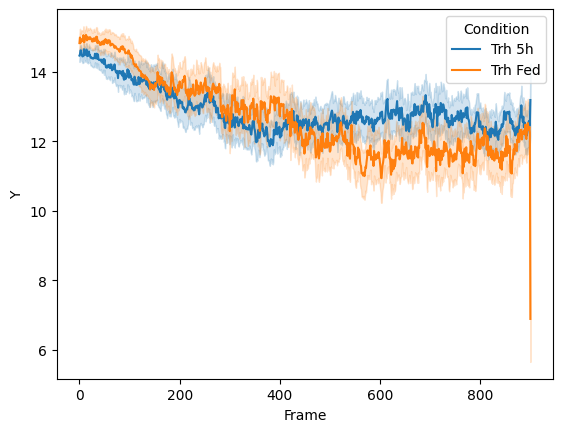

In [30]:
#Plotting Y Axis vs Time

ax = sbs.lineplot(data = y_df_trh, x = "Frame", y = "Y", hue="Condition", errorbar="se")
plt.show()

In [31]:
y_df_wt =               clean_complete_df[(clean_complete_df["Condition"] == "WT Fed") 
                                    | (clean_complete_df["Condition"] == "WT 5h")
                                    | (clean_complete_df["Condition"] == "WT 24h") 
                                    ]



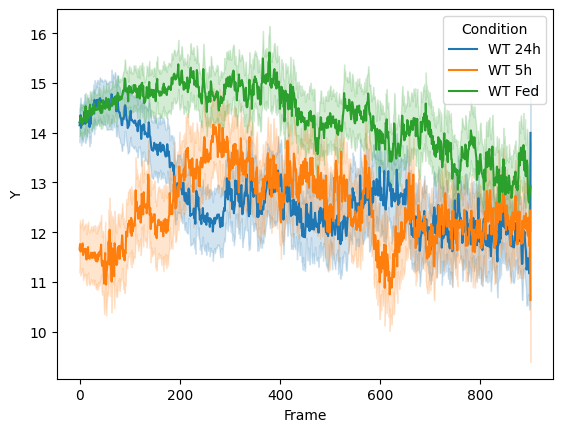

In [32]:
#Plotting Y Axis vs Time

ax = sbs.lineplot(data = y_df_wt, x = "Frame", y = "Y", hue="Condition", errorbar="se")
plt.show()